# Business Problem

Understanding how trader behavior changes under different market sentiments can help identify profitable trading patterns and support better risk management. This analysis investigates whether Fear and Greed influence trader performance, trading behavior, and decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fear_greed = pd.read_csv("../data/fear_greed.csv")
trades = pd.read_csv("../data/hyperliquid.csv")

# About the data

In [3]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fear_greed.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [6]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [7]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [8]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [9]:
fear_greed.duplicated().sum()


np.int64(0)

In [10]:
fear_greed.duplicated().sum()

np.int64(0)

## After Data Inspection I found that -

- Both datasets contain no missing values.
- No duplicate rows were found in any dataset.
- The only preprocessing required is converting the `date` and `Timestamp IST` columns from string format to datetime format for merging and analysis.

In [11]:
# changed date from string to date and time format
fear_greed["date"] = pd.to_datetime(fear_greed["date"])

In [12]:
# changed Timestamp collumn from string to date time DD-MM-YYYY HH:MM format
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [13]:
fear_greed.info()
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   str           
 3   date            2644 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 82.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  st

In [14]:
trades["date"] = trades["Timestamp IST"].dt.normalize()

In [15]:
fear_greed["date"] = fear_greed["date"].dt.normalize()

In [16]:
fear_greed["date"] = fear_greed["date"].dt.normalize()

In [17]:
trades[["Timestamp IST", "date"]].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


# merge both tables

In [18]:
merged = pd.merge(
    trades,
    fear_greed[["date", "classification", "value"]],
    on="date",
    how="left"
)

In [19]:
merged["classification"].isna().sum()

np.int64(6)

In [20]:
merged[merged["classification"].isna()]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745eb...,40671411386,False,2.719680,8.350000e+13,1.730000e+12,2024-10-26,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671438761,False,2.810115,3.230000e+14,1.730000e+12,2024-10-26,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,1.716957,1.070000e+15,1.730000e+12,2024-10-26,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.131570,8.770000e+14,1.730000e+12,2024-10-26,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.009605,9.820000e+14,1.730000e+12,2024-10-26,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd4...,40671466136,False,1.124277,9.360000e+14,1.730000e+12,2024-10-26,NaN,NaN


In [21]:
merged = merged.dropna(subset=["classification"])

In [22]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'value'],
      dtype='str')

# Core metrics

# Daily PnL per trader

In [23]:
daily_pnl = (
    merged.groupby(["date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


# Win Rate

In [24]:
merged["Win"] = merged["Closed PnL"] > 0

In [25]:
win_rate = (
    merged.groupby("Account")["Win"]
    .mean()
    .reset_index()
)

win_rate.rename(columns={"Win": "Win Rate"}, inplace=True)

win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


# Average Trade size

In [26]:
average_trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index()
)

average_trade_size.rename(columns={"Size USD": "Average Trade Size (USD)"}, inplace=True)

average_trade_size.head()

,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


# number of trades per day

In [27]:
trades_per_day = (
    merged.groupby("date")
    .size()
    .reset_index(name="Number of Trades")
)

trades_per_day.head()

,date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [28]:
merged["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [29]:
opening_trades = merged[
    merged["Direction"].isin(["Open Long", "Open Short"])
]

In [30]:
opening_trades["Direction"].value_counts()

Direction
Open Long     49895
Open Short    39741
Name: count, dtype: int64

# Overall Long/short Ratio

In [31]:
counts = opening_trades["Direction"].value_counts()

long_short_ratio = counts["Open Long"] / counts["Open Short"]

print(long_short_ratio)

1.25550439093128


For every 1 Short position opened, traders opened about 1.26 Long positions.

# The provided dataset does not include a leverage field. Therefore, leverage distribution analysis could not be performed.

# question - Does trader performance differ between Fear vs. Greed days?

In [32]:
# i am calculating average pnl classification wise
avg_pnl = (
    merged.groupby("classification")["Closed PnL"]
    .mean()
    .reset_index()
    .sort_values("Closed PnL", ascending=False)
)

avg_pnl

,classification,Closed PnL
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
0,Extreme Fear,34.537862
4,Neutral,34.307718


Trades executed during Extreme Greed were associated with the highest average Closed PnL in the dataset but this average could be distorted by a few extremely profitable trades

In [33]:
# I am calculating median pnl to check if there was any outlier or outliers
median_pnl = (
    merged.groupby("classification")["Closed PnL"]
    .median()
    .reset_index()
    .sort_values("Closed PnL", ascending=False)
)

median_pnl

,classification,Closed PnL
0,Extreme Fear,0.0
1,Extreme Greed,0.0
2,Fear,0.0
3,Greed,0.0
4,Neutral,0.0


In [34]:
#checking why median is 0?
(merged["Closed PnL"] == 0).sum()

np.int64(106816)

# More than 50% of records have a Closed PnL of zero, indicating many trades represent position openings or transactions without realized profit/loss. To evaluate trading performance more accurately, profitability metrics are computed using only trades with non-zero realized PnL

In [35]:
#making a new data frame only for those trades that are not 0 
closed_trades = merged[merged["Closed PnL"] != 0]

In [36]:
avg_pnl_closed = (
    closed_trades.groupby("classification")["Closed PnL"]
    .mean()
    .reset_index()
    .sort_values("Closed PnL", ascending=False)
)

avg_pnl_closed

,classification,Closed PnL
1,Extreme Greed,130.205309
2,Fear,112.625988
3,Greed,85.403927
4,Neutral,71.199993
0,Extreme Fear,71.027316


In [37]:
median_pnl_closed = (
    closed_trades.groupby("classification")["Closed PnL"]
    .median()
    .reset_index()
    .sort_values("Closed PnL", ascending=False)
)

median_pnl_closed

,classification,Closed PnL
1,Extreme Greed,8.530740
0,Extreme Fear,6.388050
2,Fear,6.350483
3,Greed,4.927600
4,Neutral,4.583458


* Extreme Greed has the highest average and median Closed PnL, indicating the strongest overall trading performance among all sentiment categories.
* Fear days have a higher average Closed PnL than normal Greed days, showing that traders did not necessarily perform better just because market      sentiment was positive. 
* The average PnL is much higher than the median PnL across all sentiment categories, indicating that a small number of highly profitable trades are pulling the average upward.
* PnL distribution is right-skewed, so both average and median should be considered together for a more reliable assessment of trading performance.

# Win Rate by Market Sentiment

In [38]:
closed_trades["Win"] = closed_trades["Closed PnL"] > 0 

In [39]:
win_rate_sentiment = (
    closed_trades.groupby("classification")["Win"]
    .mean()
    .reset_index()
    .sort_values("Win", ascending=False)
)

win_rate_sentiment

,classification,Win
1,Extreme Greed,0.891670
2,Fear,0.872886
4,Neutral,0.823889
3,Greed,0.768907
0,Extreme Fear,0.762156


# Do traders change their behavior based on market sentiment?

In [40]:
# trade frequency 
trade_frequency = (
    merged.groupby("classification")
    .size()
    .reset_index(name="Number of Trades")
    .sort_values("Number of Trades", ascending=False)
)

trade_frequency

,classification,Number of Trades
2,Fear,61837
3,Greed,50303
1,Extreme Greed,39992
4,Neutral,37686
0,Extreme Fear,21400


* Fear recorded the highest trading activity (61,837 trades), indicating traders were most active during Fear periods.
* Greed and Extreme Greed also showed high trading activity, with 50,303 and 39,992 trades respectively, suggesting active participation during  bullish market sentiment.
* Extreme Fear had the lowest number of trades (21,400), indicating traders were comparatively less active during periods of extreme pessimism.

# Do traders change behavior based on sentiment?

In [41]:
#average trade size by classification
avg_trade_size = (
    merged.groupby("classification")["Size USD"]
    .mean()
    .reset_index()
    .sort_values("Size USD", ascending=False)
)

avg_trade_size

,classification,Size USD
2,Fear,7816.109931
3,Greed,5736.884375
0,Extreme Fear,5349.731843
4,Neutral,4782.732661
1,Extreme Greed,3112.251565


In [42]:
#median trade size just to check if there are some big trades pulling the average upwards
median_trade_size = (
    merged.groupby("classification")["Size USD"]
    .median()
    .reset_index()
    .sort_values("Size USD", ascending=False)
)

median_trade_size

,classification,Size USD
0,Extreme Fear,766.150
2,Fear,735.960
3,Greed,555.000
4,Neutral,547.655
1,Extreme Greed,500.050


The median trade size is substantially lower than the average across all sentiment categories, indicating that trade sizes are highly right-skewed. A relatively small number of large trades significantly increase the average trade size.

In [43]:
long_short_sentiment = (
    merged[merged["Direction"].isin(["Open Long", "Open Short"])]
    .groupby(["classification", "Direction"])
    .size()
    .unstack(fill_value=0)
)

long_short_sentiment

Direction,Open Long,Open Short
classification,,
Extreme Fear,7005,3174
Extreme Greed,6300,7663
Fear,17824,10887
Greed,8544,11664
Neutral,10222,6353


In [44]:
long_short_sentiment["Long/Short Ratio"] = (
    long_short_sentiment["Open Long"] /
    long_short_sentiment["Open Short"]
)

long_short_sentiment

Direction,Open Long,Open Short,Long/Short Ratio
classification,,,
Extreme Fear,7005,3174,2.206994
Extreme Greed,6300,7663,0.822132
Fear,17824,10887,1.637182
Greed,8544,11664,0.732510
Neutral,10222,6353,1.609004


* During Extreme Fear, traders showed the strongest preference for buying rather than selling, suggesting they expected the market to recover despite negative sentiment.
* On Fear and Neutral days, traders were generally more inclined to buy than sell, indicating greater confidence in future price movements.
* During Greed and Extreme Greed, traders sold more often than they bought, suggesting many expected prices to stop rising or move lower after strong market optimism.
* Overall, trader decisions changed with market sentiment. Buying activity dominated during fearful markets, while selling activity became more common during optimistic markets.

# Identify trader segments

In [45]:
trader_activity = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Total Trades")
)

trader_activity.head()

,Account,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


Segment 1 — Frequent vs Infrequent Traders

In [46]:
trader_activity["Total Trades"].describe()

count       32.000000
mean      6600.562500
std       8250.495093
min        332.000000
25%       1377.250000
50%       3699.000000
75%       8862.500000
max      40184.000000
Name: Total Trades, dtype: float64

In [47]:
median_trades = trader_activity["Total Trades"].median()

trader_activity["Segment"] = trader_activity["Total Trades"].apply(
    lambda x: "Frequent Trader" if x > median_trades else "Infrequent Trader"
)

In [48]:
trader_activity["Segment"].value_counts()

Segment
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

In [49]:
merged = merged.merge(
    trader_activity[["Account", "Segment"]],
    on="Account",
    how="left"
)

In [50]:
merged[["Account", "Segment"]].head()

,Account,Segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader


In [51]:
closed_segment = merged[merged["Closed PnL"] != 0]

In [52]:
segment_pnl = (
    closed_segment.groupby("Segment")["Closed PnL"]
    .mean()
    .reset_index()
    .sort_values("Closed PnL", ascending=False)
)

segment_pnl

,Segment,Closed PnL
1,Infrequent Trader,206.088355
0,Frequent Trader,85.247203


* Infrequent traders achieved a higher average realized profit per closed trade than frequent traders.
* Frequent traders earned a lower average profit per trade despite executing many more trades.
* Trading more frequently did not result in higher average profitability per trade in this dataset.
* This suggests that trading quality may have been more important than trading quantity for realized profits.

# which group wins more

In [53]:
closed_segment["Win"] = closed_segment["Closed PnL"] > 0

In [54]:
segment_win_rate = (
    closed_segment.groupby("Segment")["Win"]
    .mean()
    .reset_index()
    .sort_values("Win", ascending=False)
)

segment_win_rate

,Segment,Win
0,Frequent Trader,0.833421
1,Infrequent Trader,0.820234


In [55]:
merged.groupby("Segment").size().reset_index(name="Total Trades")

,Segment,Total Trades
0,Frequent Trader,186957
1,Infrequent Trader,24261


In [56]:
segment_summary = (
    trader_activity
    .groupby("Segment")["Total Trades"]
    .agg(
        Number_of_Traders="count",
        Median_Trades="median",
        Average_Trades="mean"
    )
    .reset_index()
)

segment_summary["Median Trade Ratio"] = (
    segment_summary["Median_Trades"] /
    segment_summary["Median_Trades"].min()
).round(2)

segment_summary["Average Trade Ratio"] = (
    segment_summary["Average_Trades"] /
    segment_summary["Average_Trades"].min()
).round(2)

segment_summary

,Segment,Number_of_Traders,Median_Trades,Average_Trades,Median Trade Ratio,Average Trade Ratio
0,Frequent Trader,16,9206.0,11684.8125,6.92,7.71
1,Infrequent Trader,16,1330.5,1516.3125,1.00,1.00


| Segment                 | Meaning                                                                                                             |
| ----------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Number_of_Traders**   | There are **16 frequent** and **16 infrequent** traders.                                                            |
| **Median_Trades**       | A frequent trader executed **9,206 trades**, while a typical infrequent trader executed **1,330.5 trades**. |
| **Average_Trades**      | On average, frequent traders executed **11,684.8 trades**, while infrequent traders executed **1,516.3 trades**.    |
| **Median Trade Ratio**  | A frequent trader made **6.92×** more trades than a typical infrequent trader.                              |
| **Average Trade Ratio** | On average, frequent traders made **7.71×** more trades than infrequent traders.                                    |


In [57]:
trader_profit = (
    closed_segment.groupby(["Account", "Segment"])["Closed PnL"]
    .sum()
    .reset_index(name="Total Profit")
)

profit_summary = (
    trader_profit.groupby("Segment")["Total Profit"]
    .agg(
        Number_of_Traders="count",
        Median_Profit_per_Trader="median",
        Average_Profit_per_Trader="mean"
    )
    .reset_index()
)

profit_summary

,Segment,Number_of_Traders,Median_Profit_per_Trader,Average_Profit_per_Trader
0,Frequent Trader,16,220720.342135,496527.661215
1,Infrequent Trader,16,90788.850522,144377.773117


Frequent traders generated higher overall profits per trader, while infrequent traders achieved higher profit on each individual trade.

* Efficiency → Profit per trade (Infrequent traders perform better)
* Overall profitability → Total profit per trader (Frequent traders perform better)

# Which group changes behavior during Fear?

In [58]:
fear_data = merged[merged["classification"] == "Fear"]

In [59]:
fear_data.groupby("Segment").size().reset_index(name="Number of Trades")

,Segment,Number of Trades
0,Frequent Trader,55621
1,Infrequent Trader,6216


In [60]:
fear_data.groupby("Segment")["Size USD"].median().reset_index(name="Median Trade Size")

,Segment,Median Trade Size
0,Frequent Trader,723.720
1,Infrequent Trader,813.975


In [61]:
fear_data.groupby("Segment")["Size USD"].mean().reset_index(name="Average Trade Size")

,Segment,Average Trade Size
0,Frequent Trader,8162.301977
1,Infrequent Trader,4718.370584


In [62]:
fear_profit_summary = (
    merged[
        (merged["classification"] == "Fear") &
        (merged["Closed PnL"] != 0)
    ]
    .groupby(["Account", "Segment"])["Closed PnL"]
    .sum()
    .reset_index(name="Total Profit During Fear")
    .groupby("Segment")["Total Profit During Fear"]
    .agg(
        Number_of_Traders="count",
        Median_Profit_per_Trader="median",
        Average_Profit_per_Trader="mean"
    )
    .reset_index()
)

fear_profit_summary

,Segment,Number_of_Traders,Median_Profit_per_Trader,Average_Profit_per_Trader
0,Frequent Trader,16,50528.317187,178417.510456
1,Infrequent Trader,16,4146.555814,31404.704647


| Metric                   | Frequent Traders | Infrequent Traders | What it means                                                                             |
| ------------------------ | ---------------: | -----------------: | ----------------------------------------------------------------------------------------- |
| Number of Trades         |           55,621 |              6,216 | Frequent traders stayed more active during Fear.                                     |
| Median Trade Size        |           723.72 |             813.98 | A typical trade size was similar, with infrequent traders placing slightly larger trades. |
| Median Profit per Trader |           50,528 |              4,147 | A typical frequent trader earned much more profit during Fear.                            |
| Average Trade Size       |            8,162 |              4,718 | Frequent traders occasionally placed much larger trades, increasing the average.          |


In [63]:
trader_winrate = (
    merged[merged["Closed PnL"] != 0]
    .assign(Win=lambda x: x["Closed PnL"] > 0)
    .groupby("Account")["Win"]
    .mean()
    .reset_index(name="Win Rate")
)

trader_winrate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.792725
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.773644
2,0x271b280974205ca63b716753467d5a371de622ab,0.715619
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.862079
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.817476


# Consistent Winners vs Inconsistent Traders

In [64]:
trader_winrate = (
    merged[merged["Closed PnL"] != 0]
    .assign(Win=lambda x: x["Closed PnL"] > 0)
    .groupby("Account")["Win"]
    .mean()
    .reset_index(name="Win Rate")
)

trader_winrate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.792725
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.773644
2,0x271b280974205ca63b716753467d5a371de622ab,0.715619
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.862079
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.817476


In [65]:
trader_winrate["Win Rate"].describe()

count    32.000000
mean      0.850043
std       0.117715
min       0.599024
25%       0.760363
50%       0.842041
75%       0.953957
max       1.000000
Name: Win Rate, dtype: float64

In [66]:
median_winrate = trader_winrate["Win Rate"].median()

trader_winrate["Segment"] = trader_winrate["Win Rate"].apply(
    lambda x: "Consistent Winner" if x > median_winrate else "Inconsistent Trader"
)

trader_winrate["Segment"].value_counts()

Segment
Inconsistent Trader    16
Consistent Winner      16
Name: count, dtype: int64

In [67]:
merged = merged.merge(
    trader_winrate[["Account", "Segment"]],
    on="Account",
    how="left",
    suffixes=("", "_Win")
)

merged.rename(columns={"Segment_Win": "Winner Segment"}, inplace=True)

In [68]:
winner_activity = (
    merged.groupby("Winner Segment")["Account"]
    .count()
    .reset_index(name="Total Trades")
)

winner_activity

,Winner Segment,Total Trades
0,Consistent Winner,94606
1,Inconsistent Trader,116612


In [69]:
winner_trader_activity = (
    merged.groupby(["Account", "Winner Segment"])
    .size()
    .reset_index(name="Total Trades")
    .groupby("Winner Segment")["Total Trades"]
    .agg(
        Number_of_Traders="count",
        Median_Trades="median",
        Average_Trades="mean"
    )
    .reset_index()
)

winner_trader_activity

,Winner Segment,Number_of_Traders,Median_Trades,Average_Trades
0,Consistent Winner,16,2481.5,5912.875
1,Inconsistent Trader,16,3813.5,7288.250


In [70]:
winner_trade_size = (
    merged.groupby("Winner Segment")["Size USD"]
    .median()
    .reset_index(name="Median Trade Size")
)

winner_trade_size

,Winner Segment,Median Trade Size
0,Consistent Winner,660.71
1,Inconsistent Trader,555.00


| Metric                    | Consistent Winners | Inconsistent Traders | Observation                                                |
| ------------------------- | -----------------: | -------------------: | ---------------------------------------------------------- |
| Total Trades              |             94,606 |              116,612 | Inconsistent traders executed more trades overall.         |
| Median Trades per Trader  |            2,481.5 |              3,813.5 | A typical inconsistent trader traded more frequently.      |
| Average Trades per Trader |            5,912.9 |              7,288.3 | Inconsistent traders were also more active on average.     |
| Median Trade Size         |             660.71 |               555.00 | Consistent winners usually took slightly larger positions. |


# Simple observations:
* Consistent winners were not the most active traders; they actually traded less frequently than inconsistent traders.
* Higher trading frequency did not directly translate into better results, as inconsistent traders executed more trades but had lower win rates.
* Consistent winners used slightly larger typical trade sizes, suggesting they may have been more selective with their opportunities.
* The results suggest that trading quality and decision-making may matter more than simply increasing the number of trades.

# Are consistent winners less affected by market emotions?

In [71]:
winner_sentiment_profit = (
    merged[merged["Closed PnL"] != 0]
    .groupby(["classification", "Winner Segment", "Account"])["Closed PnL"]
    .sum()
    .reset_index(name="Total Profit")
    .groupby(["classification", "Winner Segment"])["Total Profit"]
    .median()
    .reset_index(name="Median Profit per Trader")
)
winner_sentiment_profit

,classification,Winner Segment,Median Profit per Trader
0,Extreme Fear,Consistent Winner,2037.258612
1,Extreme Fear,Inconsistent Trader,11415.247787
2,Extreme Greed,Consistent Winner,47101.257446
3,Extreme Greed,Inconsistent Trader,22699.283318
4,Fear,Consistent Winner,6872.196380
5,Fear,Inconsistent Trader,40907.134601
6,Greed,Consistent Winner,41169.082798
7,Greed,Inconsistent Trader,21077.717000
8,Neutral,Consistent Winner,11213.565797
9,Neutral,Inconsistent Trader,4029.241688


| Market Condition | Consistent Winners (Median Profit/Trader) | Inconsistent Traders (Median Profit/Trader) | Observation                                                                                                                           |
| ---------------- | ----------------------------------------: | ------------------------------------------: | ------------------------------------------------------------------------------------------------------------------------------------- |
| Extreme Fear     |                                     2,037 |                                      11,415 | Inconsistent traders earned higher profits, suggesting some traders benefited from aggressive decisions during extreme market stress. |
| Fear             |                                     6,872 |                                      40,907 | Inconsistent traders performed significantly better during fearful conditions, possibly by taking higher-risk opportunities.          |
| Neutral          |                                    11,214 |                                       4,029 | Consistent winners performed better during normal market conditions, showing more stable performance.                                 |
| Greed            |                                    41,169 |                                      21,078 | Consistent winners generated higher profits when market sentiment was positive.                                                       |
| Extreme Greed    |                                    47,101 |                                      22,699 | Consistent winners captured more profit during highly optimistic market conditions.                                                   |


* Consistent winners showed stronger performance during normal and bullish market conditions, while inconsistent traders generated higher profits during fearful conditions. This suggests that some traders may benefit from high-volatility opportunities, whereas consistent winners demonstrate more stable performance across regular market environments.

# Large Position Traders vs Small Position Traders

In [72]:
trader_size = (
    merged.groupby("Account")["Size USD"]
    .median()
    .reset_index(name="Median Trade Size")
)

trader_size.head()

,Account,Median Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1348.160
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,462.815
2,0x271b280974205ca63b716753467d5a371de622ab,1116.380
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,148.310
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,958.550


In [73]:
median_size = trader_size["Median Trade Size"].median()

trader_size["Position Segment"] = trader_size["Median Trade Size"].apply(
    lambda x: "Large Position Trader" if x > median_size else "Small Position Trader"
)

trader_size["Position Segment"].value_counts()

Position Segment
Large Position Trader    16
Small Position Trader    16
Name: count, dtype: int64

In [74]:
merged = merged.merge(
    trader_size[["Account", "Position Segment"]],
    on="Account",
    how="left"
)

In [75]:
merged = merged.merge(
    trader_size[["Account", "Position Segment"]],
    on="Account",
    how="left"
)

In [76]:
merged.drop(columns=["Position Segment_y"], inplace=True)

merged.rename(
    columns={"Position Segment_x": "Position Segment"},
    inplace=True
)

In [77]:
position_profit = (
    merged[merged["Closed PnL"] != 0]
    .groupby(["Account", "Position Segment"])["Closed PnL"]
    .sum()
    .reset_index(name="Total Profit")
    .groupby("Position Segment")["Total Profit"]
    .agg(
        Number_of_Traders="count",
        Median_Profit_per_Trader="median",
        Average_Profit_per_Trader="mean"
    )
    .reset_index()
)

position_profit

,Position Segment,Number_of_Traders,Median_Profit_per_Trader,Average_Profit_per_Trader
0,Large Position Trader,16,147618.473564,296694.753028
1,Small Position Trader,16,107517.046014,344210.681303


# Does larger position size improve profitability?

In [78]:
position_winrate = (
    merged[merged["Closed PnL"] != 0]
    .groupby(["Position Segment"])["Win"]
    .mean()
    .reset_index(name="Win Rate")
)

position_winrate

,Position Segment,Win Rate
0,Large Position Trader,0.843435
1,Small Position Trader,0.828463


In [79]:
position_activity = (
    merged.groupby(["Account", "Position Segment"])
    .size()
    .reset_index(name="Total Trades")
    .groupby("Position Segment")["Total Trades"]
    .agg(
        Number_of_Traders="count",
        Median_Trades="median",
        Average_Trades="mean"
    )
    .reset_index()
)

position_activity

,Position Segment,Number_of_Traders,Median_Trades,Average_Trades
0,Large Position Trader,16,3145.5,3404.6875
1,Small Position Trader,16,7899.5,9796.4375


| Metric                    | Large Position Traders | Small Position Traders | Observation                                                         |
| ------------------------- | ---------------------: | ---------------------: | ------------------------------------------------------------------- |
| Win Rate                  |             **84.34%** |             **82.85%** | Large position traders had a slightly higher success rate.          |
| Median Trades per Trader  |            **3,145.5** |            **7,899.5** | A typical small position trader executed over twice as many trades. |
| Average Trades per Trader |            **3,404.7** |            **9,796.4** | Small position traders were much more active overall.               |


* Large position traders achieved a slightly higher win rate despite trading much less frequently.
* Small position traders executed more than twice as many trades, but this higher activity did not result in a higher win rate.
* The results suggest that larger position traders were more selective in choosing their trades rather than trading more often.
* Trading more frequently alone did not improve trading consistency in this dataset.

# Does sentiment affect large and small position traders differently?

In [80]:
position_sentiment_profit = (
    merged[merged["Closed PnL"] != 0]
    .groupby(["classification", "Position Segment", "Account"])["Closed PnL"]
    .sum()
    .reset_index(name="Total Profit")
    .groupby(["classification", "Position Segment"])["Total Profit"]
    .median()
    .reset_index(name="Median Profit per Trader")
)

position_sentiment_profit


,classification,Position Segment,Median Profit per Trader
0,Extreme Fear,Large Position Trader,9461.082288
1,Extreme Fear,Small Position Trader,2037.258612
2,Extreme Greed,Large Position Trader,14406.384865
3,Extreme Greed,Small Position Trader,56071.411053
4,Fear,Large Position Trader,22332.306712
5,Fear,Small Position Trader,11466.976786
6,Greed,Large Position Trader,38168.354860
7,Greed,Small Position Trader,30697.996504
8,Neutral,Large Position Trader,12960.109958
9,Neutral,Small Position Trader,2643.681306


* Large position traders outperformed in 4 out of the 5 market conditions.
* Their strongest performance was during Fear, Extreme Fear, Greed, and Neutral markets.
* Small position traders only outperformed during Extreme Greed.
* This suggests that traders taking larger positions generally achieved better profitability across most market conditions, while smaller position * traders appeared to benefit more when market optimism became extremely high.

A reasonable explanation 

* Large position traders may be more selective, taking fewer but higher-conviction trades, which helps them perform well in most market environments.
* Extreme Greed often brings strong price rallies. Small position traders may participate in these moves more aggressively or for longer, allowing them to outperform during periods of excessive optimism.

# Data Visualization & Interpretation

Average Closed PnL by Market Sentiment

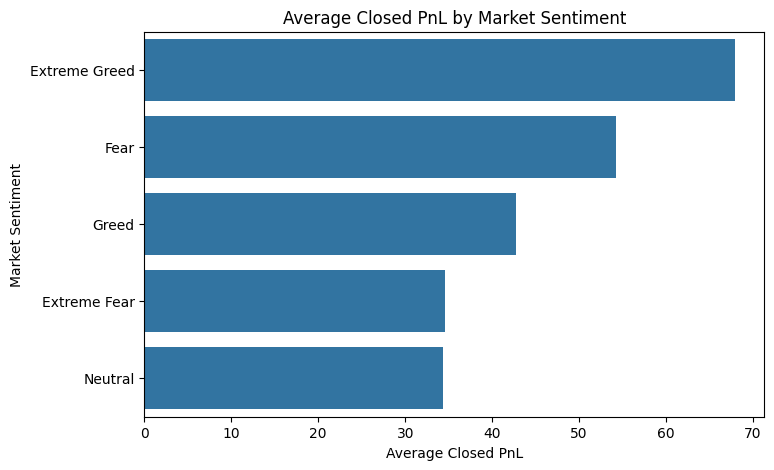

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_pnl,
    x="Closed PnL",
    y="classification"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Average Closed PnL")
plt.ylabel("Market Sentiment")

plt.show()

Interpretation:

Traders earned the highest average profit during Extreme Greed.
Fear was the second most profitable market condition.
Neutral markets gave the lowest average profit.
Overall, stronger market sentiment was linked with higher average profits.

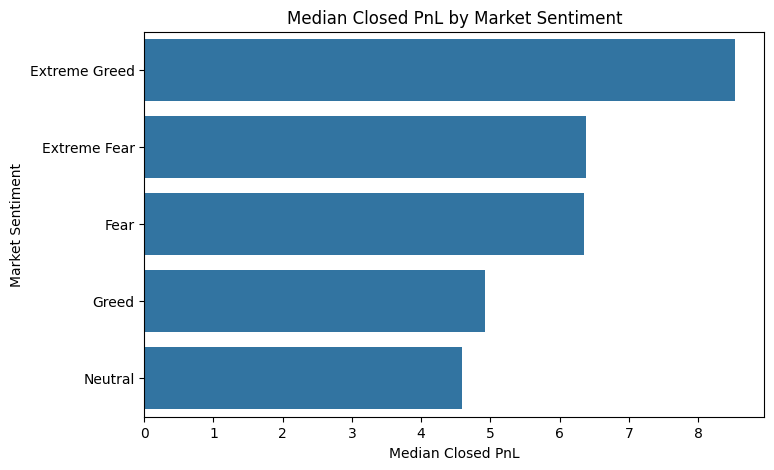

In [103]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=median_pnl_closed,
    x="Closed PnL",
    y="classification"
)

plt.title("Median Closed PnL by Market Sentiment")
plt.xlabel("Median Closed PnL")
plt.ylabel("Market Sentiment")

plt.show()

Interpretation:

A typical trader also earned the highest profit during Extreme Greed.
Fear and Greed performed better than Neutral.
Since the median is not affected much by very large profits, this result is more reliable for showing a typical trader's performance.

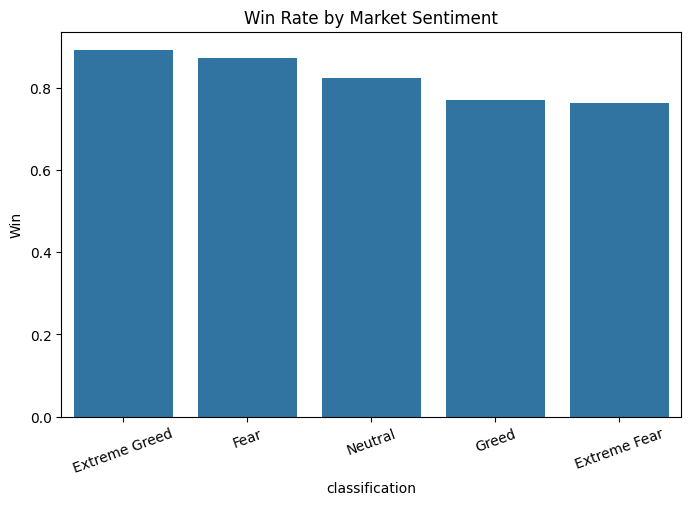

In [91]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate_sentiment,
    x="classification",
    y="Win"
)

plt.title("Win Rate by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

Interpretation:

Traders had the highest chance of making a profitable trade during Extreme Greed.
Win rates were lower during Greed and Extreme Fear.
This shows that market sentiment can affect how often traders make successful trades.

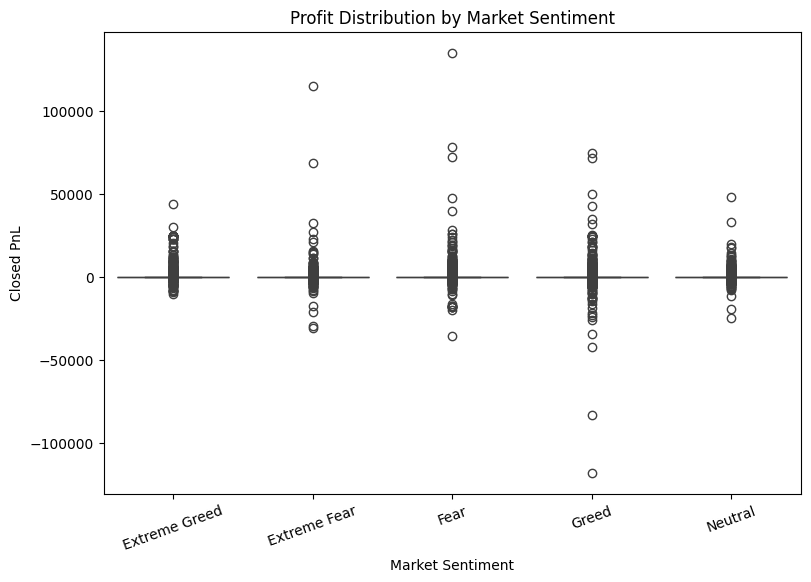

In [84]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Profit Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=20)

plt.show()

Interpretation:

Profits were spread differently across different market conditions.
Some sentiments had a much wider range of profits and losses.
This means trading results become more unpredictable under certain market conditions.

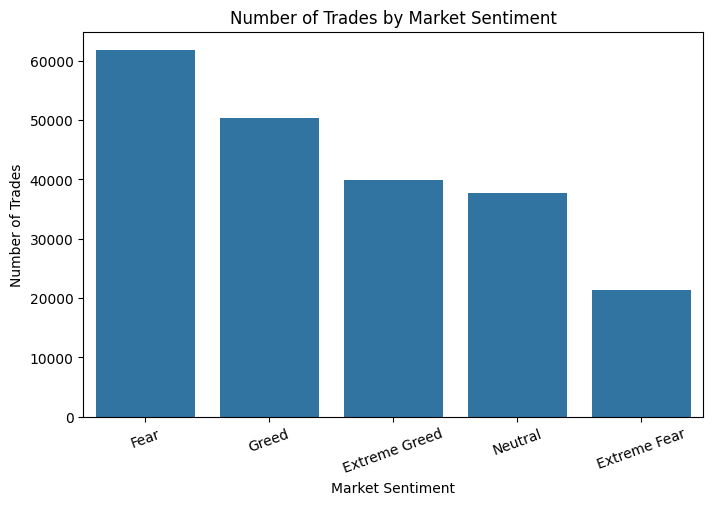

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Number of Trades"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

Interpretation:

Traders placed the most trades during Fear.
Extreme Fear had the lowest trading activity.
This suggests that traders were more active during moderate market emotions than during extreme panic.

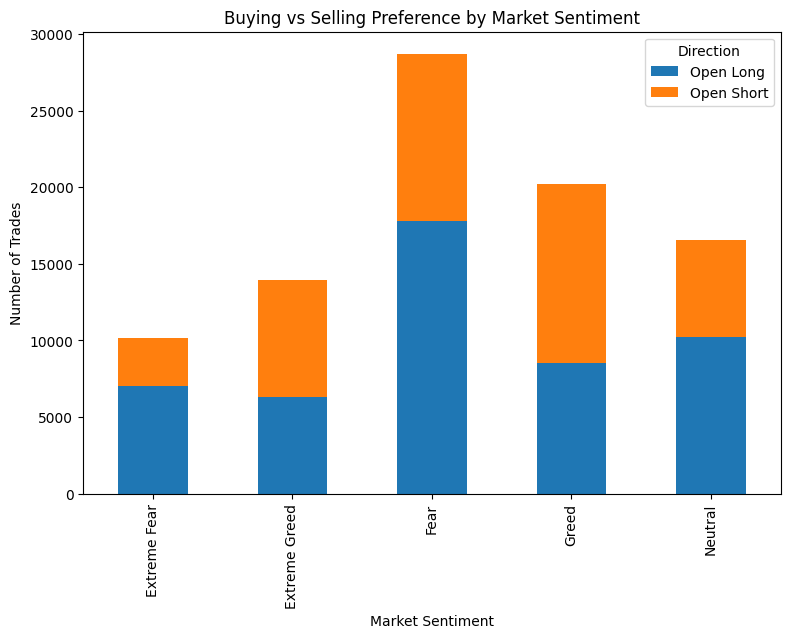

In [101]:
long_short_sentiment[["Open Long","Open Short"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.title("Buying vs Selling Preference by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Interpretation:

Traders changed their trading direction based on market sentiment.
In some market conditions they expected prices to rise more often, while in others they expected prices to fall more often.
This shows that trader decisions change as market sentiment changes.

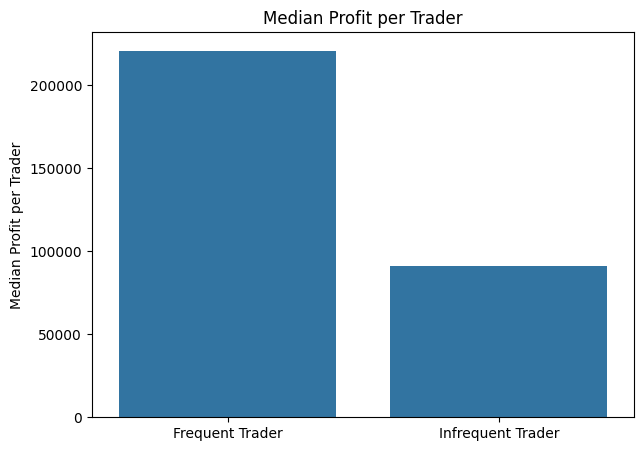

In [100]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=profit_summary,
    x="Segment",
    y="Median_Profit_per_Trader"
)

plt.title("Median Profit per Trader")
plt.xlabel("")
plt.ylabel("Median Profit per Trader")

plt.show()

Interpretation:

Frequent traders earned higher profits per trader.
They also had a slightly higher win rate.
This suggests that frequent traders performed better overall in this dataset.

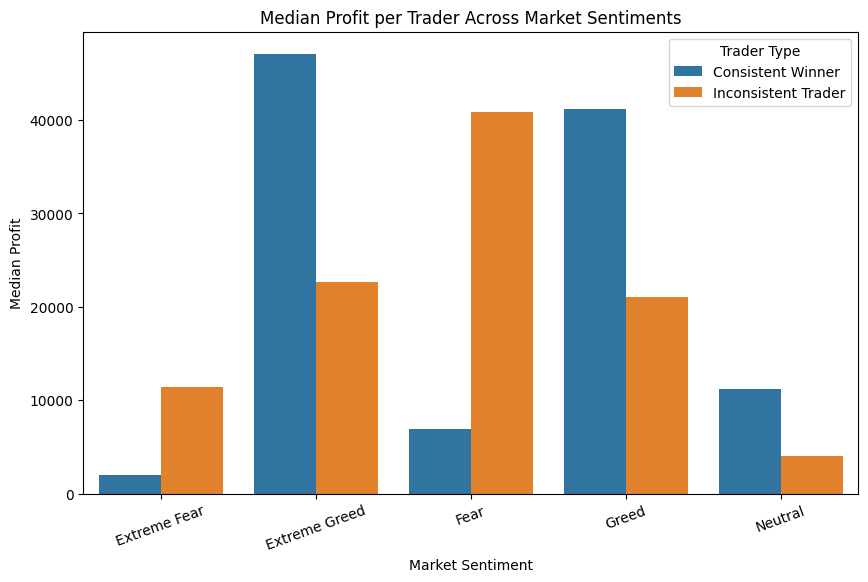

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=winner_sentiment_profit,
    x="classification",
    y="Median Profit per Trader",
    hue="Winner Segment"
)

plt.title("Median Profit per Trader Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Median Profit")

plt.xticks(rotation=20)

plt.legend(title="Trader Type")

plt.show()

Interpretation:

Consistent winners earned more during Neutral, Greed, and Extreme Greed.
Inconsistent traders earned more during Fear and Extreme Fear.
This shows that different types of traders performed better under different market conditions.

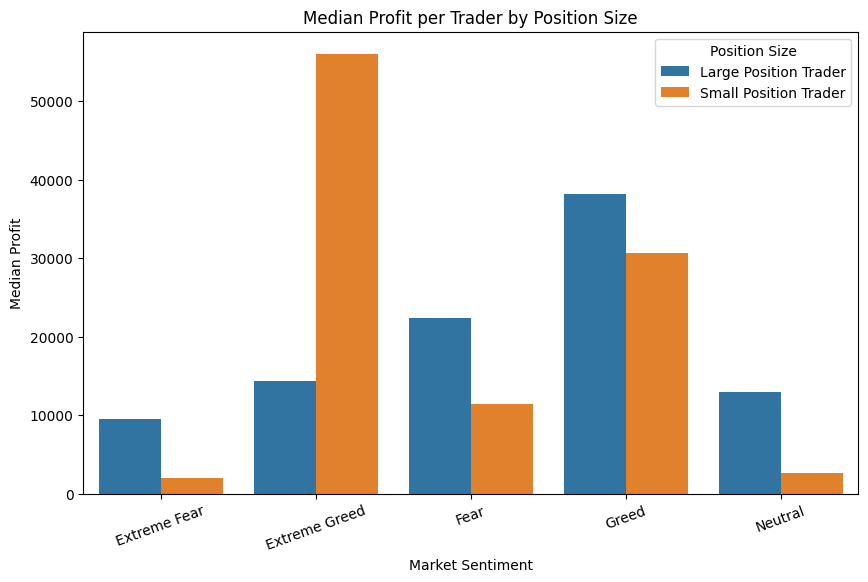

In [89]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=position_sentiment_profit,
    x="classification",
    y="Median Profit per Trader",
    hue="Position Segment"
)

plt.title("Median Profit per Trader by Position Size")
plt.xlabel("Market Sentiment")
plt.ylabel("Median Profit")

plt.xticks(rotation=20)

plt.legend(title="Position Size")

plt.show()

Interpretation:

Large position traders earned higher profits in most market conditions.
Small position traders performed better only during Extreme Greed.
Overall, traders with larger positions performed better in this dataset.

# **Executive Summary**

**Methodology**

This project looks at how market sentiment affects trading performance on Hyperliquid. I used two datasets: the Fear & Greed Index and Hyperliquid trading records. After cleaning both, I merged them by trading date so each trade could be looked at alongside the market sentiment at that time. I then compared trader performance across different market conditions using profit, win rate, trading frequency, average position size, and trader type.

**Key Insights**

Traders made their best returns during Extreme Greed, while Neutral conditions gave the weakest results. During Fear, traders were more active and made more trades, showing that uncertainty led to more participation instead of less.

Frequent traders had higher total profits and a slightly better win rate than occasional traders, but this is mostly because they made more trades, giving them more chances to profit. Traders who took bigger positions also did better in most conditions, even though they traded less often.

Sentiment also affected trader groups differently. Consistently strong traders performed better during Greed and Neutral markets, while less consistent traders did relatively better during Fear.

**Strategy Recommendations**

Traders shouldn't trade more just because markets get volatile. During Fear, sticking to fewer, well-chosen trades seems to work better than trading a lot. Performance should be measured using median profit and win rate, not just total profit, since higher trading volume naturally leads to bigger totals regardless of skill. Using market sentiment in trading decisions can help traders adjust — trading more during Greed and being more careful during Fear.